In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import xarray as xr
import numpy as np
from distributed import Client, LocalCluster
import dask
import pickle
import os
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import linregress
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, Matern, RationalQuadratic
import joblib # For saving our models
import time
import emcee
from matplotlib.ticker import FuncFormatter
import numpy as np
import pickle
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

plt.rcParams['text.usetex'] = True
import corner # The library for creating corner plots

# Loadings neaded for LaTex

In [4]:
# Get the current PATH
original_path = os.environ.get('PATH', '')
latex_path = '/glade/u/apps/casper/24.12/spack/opt/spack/texlive/20240312/gcc/12.4.0/nm7e/bin/x86_64-linux' 
# Prepend the LaTeX path to the system's PATH
# We prepend it to make sure it's found first.
os.environ['PATH'] = latex_path + os.pathsep + original_path
plt.rcParams['text.usetex'] = True

# Load regime & control dataframes

In [5]:
read_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_regime2 = pd.read_pickle(read_path+'df_regime2_perturbed_members.pkl')
df_cntl_regime2 = pd.read_pickle(read_path+'df_regime2_cntl.pkl')
df_cntl = pd.read_pickle(read_path+'df_all_regimes_cntl.pkl')
print(df_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl[['RESTOM_PD', 'LWP_PD_regime2', 'WROF_PD_regime2','PAF_PD_regime2']].T)

                  0          1          2           3          4          5   \
RESTOM_PD  22.767999  10.145342  17.262480   -6.977647  21.915214  21.711642   
LWP_PD      3.057743  37.931980  10.159395  147.974965   5.190044   4.751587   
WROF_PD     0.799337   0.885769   0.920615    0.054271   0.803136   0.778199   
PAF_PD      0.005089   0.004556   0.004543    0.063875   0.002875   0.003208   

                   6          7          8           9   ...         40  \
RESTOM_PD   -7.650290  19.457138  14.639741   -2.185409  ...  -1.116216   
LWP_PD     148.395507  13.462151  14.315497  110.949258  ...  86.064168   
WROF_PD      0.053720   0.941904   0.942558    0.342422  ...   0.520146   
PAF_PD       0.062392   0.010737   0.009245    0.015458  ...   0.008924   

                   41         42          43         44         45         46  \
RESTOM_PD   -7.637161  23.359594   -7.432411  16.070160  16.228917  19.658779   
LWP_PD     148.083371   4.195462  148.166729  15.888349  10.1

# Load Scaler and transforms files

In [6]:
# Load scalar and transforms
scaler_file = './emulators_production/global_x_scaler.joblib'
global_x_scaler = joblib.load(scaler_file)
transform_file = './emulators_production/production_transforms.joblib'
transforms = joblib.load(transform_file)

## Read in dense priors dictionary and convert to Dataframe
### Note: This assumes that emulator error is propagated into the dense prior

In [7]:
read_path='/glade/u/home/mckenna/work/'
with open(read_path+'dense_priors_dict.pkl', 'rb') as file:
    dense_priors = pickle.load(file)
df_dense_priors = pd.DataFrame.from_dict(dense_priors)

In [32]:
# --- 1. PRE-CALCULATION OF ALL SURFACES ---

print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function for a single-variable likelihood surface
def calculate_independent_likelihood_surface(theta_grid, var_name, emulator, observation, error, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred, pred_std = emulator.predict(theta_point, return_std=True)
            total_variance = error**2
            if include_emulator_uncertainty:
                total_variance += pred_std[0]**2
            scores[i, j] = -0.5 * ((pred[0] - observation)**2 / total_variance)
    return scores

# Helper function for correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    obs_vector = np.array([observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector, pred_stds = [], []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector.append(pred[0]); pred_stds.append(std[0])
            
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty:
                total_variances += np.array(pred_stds)**2
            
            total_stds = np.sqrt(total_variances)
            Sigma_total = np.diag(total_stds) @ R_matrix @ np.diag(total_stds)
            
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = np.array(pred_vector) - obs_vector
                scores[i, j] = -0.5 * (residual_vector @ inv_Sigma_total @ residual_vector)
            except np.linalg.LinAlgError:
                scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD']
prediction_surfaces, emulators, observations = {}, {}, {}

global_x_scaler = joblib.load('./emulators_production/global_x_scaler.joblib')
n_points_plot = 100
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production/gp_production_{var_name}.joblib')
    observations[var_name] = df_cntl_regime2[var_name].iloc[0] if var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD','AUTOCONV_PD','ACCRETN_PD'] else df_cntl[var_name].iloc[0]
observations['AUTOCONV_PD'] = np.log(observations['AUTOCONV_PD'])
observations['ACCRETN_PD'] = np.log(observations['ACCRETN_PD'])

#============================================================
# --- Calculate Prediction Surfaces (once) ---
#============================================================
print("  Calculating prediction surfaces...")
for var_name in ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            preds[i, j] = emulators[var_name].predict(np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]]))[0]
    prediction_surfaces[var_name] = preds

#============================================================
# --- Calculate ALL Likelihood Surfaces ---
#============================================================
likelihood_surfaces = {}
obs_error_fractions = [0.20]
#obs_error_fractions = [0.05]
errors = {'OLR_UPWELL_PD': 2.0, 'OSR_UPWELL_PD': 2.0}

# Rad-only surface (once)
print("  Calculating 'Radiation-only' likelihood surface...")
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad)

# LWP-only and Process-only surfaces for EACH error assumption
vars_prox = ['PRECL_PD', 'WROF_PD', 'PAF_PD']
vars_proc = ['AUTOCONV_PD','ACCRETN_PD']
R_prox = np.corrcoef(df_dense_priors[vars_prox].to_numpy(), rowvar=False)
R_proc = np.corrcoef(np.log(df_dense_priors[vars_proc].to_numpy()), rowvar=False)

for err_frac in obs_error_fractions:
    err_key = f'_{int(err_frac*100)}'
    print(f"  Calculating surfaces for {int(err_frac*100)}% error...")
    
    # Update errors for this iteration
    errors['LWP_PD'] = err_frac * abs(observations['LWP_PD'])
    errors['PRECL_PD'] = err_frac * abs(observations['PRECL_PD'])
    errors['WROF_PD'] = err_frac * abs(observations['WROF_PD'])
    errors['PAF_PD'] = err_frac * abs(observations['PAF_PD'])
    #errors['AUTOCONV_PD'] = err_frac * abs(observations['AUTOCONV_PD'])
    #errors['ACCRETN_PD'] = err_frac * abs(observations['ACCRETN_PD'])
    errors['AUTOCONV_PD'] = err_frac 
    errors['ACCRETN_PD'] = err_frac
    
    # Calculate LWP-only INDEPENDENT surface
    likelihood_surfaces[f'LWP_only{err_key}'] = calculate_independent_likelihood_surface(
        (x_auto_grid, x_accr_grid), 'LWP_PD', emulators['LWP_PD'], observations['LWP_PD'], errors['LWP_PD']
    )
    
    # Calculate Process-only CORRELATED surface
    likelihood_surfaces[f'Proc_only{err_key}'] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_proc, emulators, observations, errors, R_proc
    )

    # Calculate Proxy-only CORRELATED surface
    likelihood_surfaces[f'Prox_only{err_key}'] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_prox, emulators, observations, errors, R_prox
    )

# --- Transform coordinates for plotting ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")

--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating 'Radiation-only' likelihood surface...
  Calculating surfaces for 20% error...
--- All surfaces calculated. ---


In [33]:
# --- 1. PRE-CALCULATION OF ALL SURFACES (CORRECTED) ---
print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function for a single-variable likelihood surface
def calculate_independent_likelihood_surface(theta_grid, var_name, emulator, observation, error, include_emulator_uncertainty=True):
    transform_type = transforms.get(var_name, 'linear')
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    
    # If it's a log-var, do comparisons in log-space
    obs_proc = np.log(observation) if transform_type == 'log' else observation
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_proc, std_proc = emulator.predict(theta_point, return_std=True)
            
            total_variance = error**2 # Error should already be in the correct space
            if include_emulator_uncertainty:
                total_variance += std_proc[0]**2
                
            scores[i, j] = -0.5 * ((pred_proc[0] - obs_proc)**2 / total_variance)
    return scores

# Helper function for correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    
    # Create the observation vector in the correct processed space
    obs_vector_proc = np.array([np.log(observations[v]) if transforms.get(v) == 'log' else observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector_proc, pred_stds_proc = [], []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector_proc.append(pred[0]); pred_stds_proc.append(std[0])
            
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty:
                total_variances += np.array(pred_stds_proc)**2
            
            total_stds = np.sqrt(total_variances)
            Sigma_total = np.diag(total_stds) @ R_matrix @ np.diag(total_stds)
            
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = np.array(pred_vector_proc) - obs_vector_proc
                scores[i, j] = -0.5 * (residual_vector @ inv_Sigma_total @ residual_vector)
            except np.linalg.LinAlgError:
                scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD']
prediction_surfaces, emulators, observations = {}, {}, {}
global_x_scaler = joblib.load('./emulators_production/global_x_scaler.joblib')
n_points_plot = 100
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)
for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production/gp_production_{var_name}.joblib')
    observations[var_name] = df_cntl_regime2[var_name].iloc[0] if var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD','AUTOCONV_PD','ACCRETN_PD'] else df_cntl[var_name].iloc[0]

# --- Calculate Prediction Surfaces ---
print("  Calculating prediction surfaces...")
for var_name in ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD','OLR_UPWELL_PD','OSR_UPWELL_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            pred_proc = emulators[var_name].predict(np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]]))[0]
            # Convert back to physical space for plotting
            if transforms.get(var_name) == 'log':
                preds[i, j] = np.exp(pred_proc)
            else:
                preds[i, j] = pred_proc
    prediction_surfaces[var_name] = preds

# --- Calculate ALL Likelihood Surfaces ---
likelihood_surfaces = {}
obs_error_fractions = [0.20] # Or whichever you are plotting
#obs_error_fractions = [0.05] # Or whichever you are plotting
errors = {'OLR_UPWELL_PD': 2.0, 'OSR_UPWELL_PD': 2.0}
# Rad-only surface
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad)

# LWP-only and Process-only surfaces
vars_prox = ['PRECL_PD', 'WROF_PD', 'PAF_PD']
vars_proc = ['AUTOCONV_PD','ACCRETN_PD']
R_prox = np.corrcoef(df_dense_priors[vars_prox].to_numpy(), rowvar=False)
R_proc = np.corrcoef(np.log10(df_dense_priors[vars_proc] + 1e-20).to_numpy(), rowvar=False) # R must be calculated in log space

for err_frac in obs_error_fractions:
    err_key = f'_{int(err_frac*100)}'
    print(f"  Calculating surfaces for {int(err_frac*100)}% error...")
    
    # Update errors for this iteration using the CORRECT logic
    for var in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD', 'AUTOCONV_PD', 'ACCRETN_PD']:
        if transforms.get(var) == 'log':
            errors[var] = err_frac # Absolute error in log-space
        else:
            errors[var] = err_frac * abs(observations[var]) # Absolute error in linear space

    likelihood_surfaces[f'LWP_only{err_key}'] = calculate_independent_likelihood_surface((x_auto_grid, x_accr_grid), 'LWP_PD', emulators['LWP_PD'], observations['LWP_PD'], errors['LWP_PD'])
    likelihood_surfaces[f'Proc_only{err_key}'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_proc, emulators, observations, errors, R_proc)
    likelihood_surfaces[f'Prox_only{err_key}'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_prox, emulators, observations, errors, R_prox)

# --- Transform coordinates for plotting (unchanged) ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")

--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating surfaces for 20% error...
--- All surfaces calculated. ---


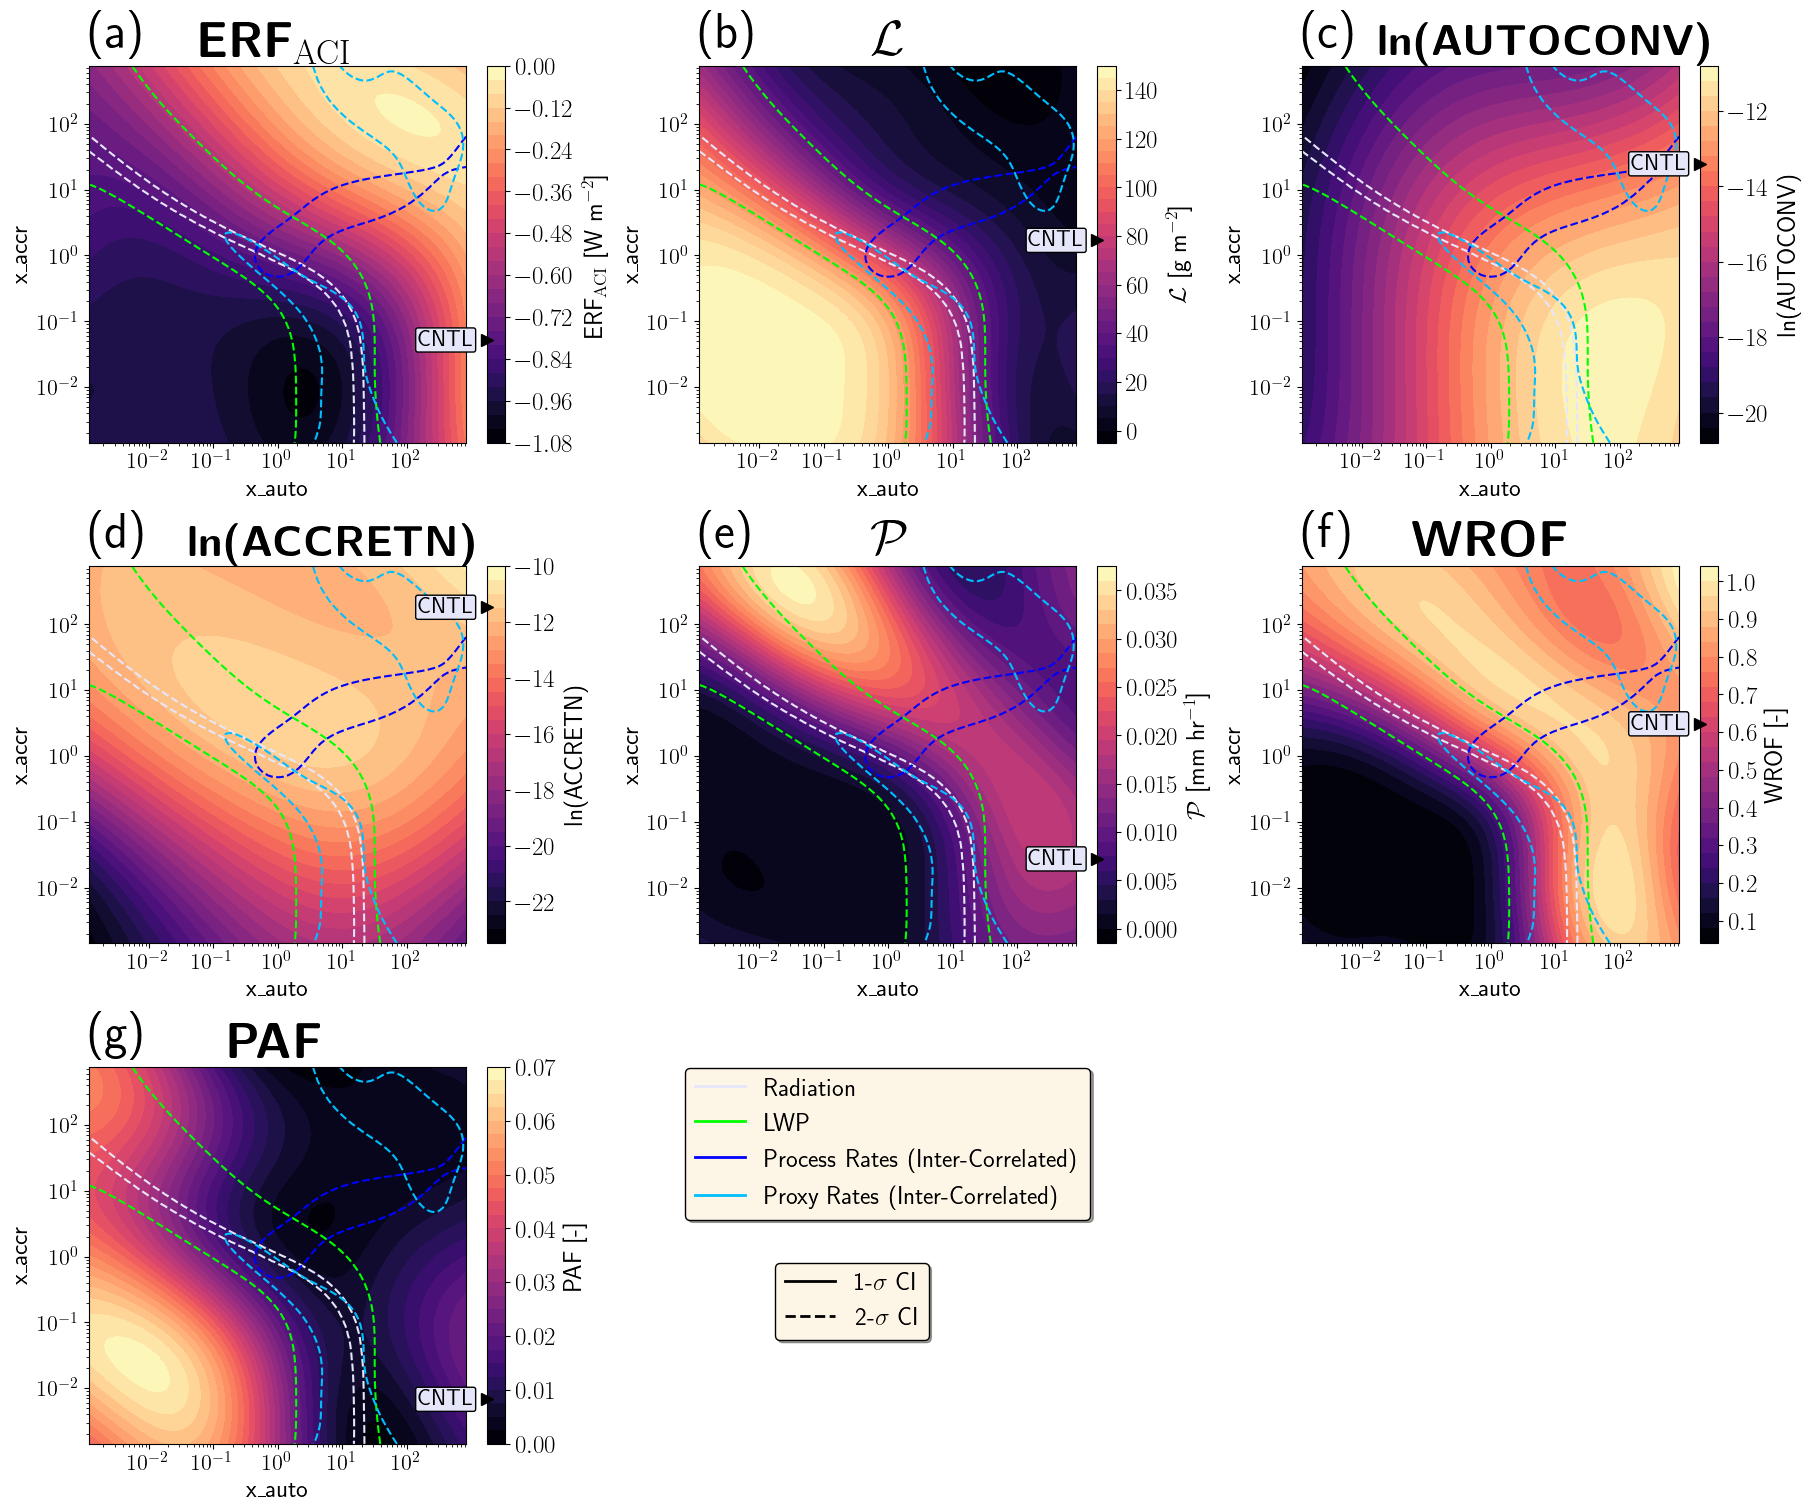

done


In [12]:
# --- PLOTTING CODE (3x3 LAYOUT, INFERNO CMAP) ---
fig, axes = plt.subplots(3, 3, figsize=(18, 15), constrained_layout=True)
axes_flat = axes.ravel()
Fontsize = 18

plot_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]','$\mathcal{L}$ [g m$^{-2}$]',\
             'ln(AUTOCONV)','ln(ACCRETN)',\
             '$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'\textbf{$\mathcal{L}$}',\
          r'\textbf{ln(AUTOCONV)}',r'\textbf{ln(ACCRETN)}',\
          r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
#confidence_delta_ll = [-3.09, -1.15] # 95% (2-sigma) and 68% (1-sigma) CIs
confidence_delta_ll = [-3.09] # 95% (2-sigma) and 68% (1-sigma) CIs

# --- Suggested Colorblind-Friendly Contour Colors for 'Inferno' ---
contour_colors = {
    'Rad': 'lavender',  # Cyan
    'LWP': 'lime',  # Lime
    'Proc': 'blue', # Magenta
    'Prox': 'deepskyblue'  # White (or 'lightgrey')
}

err_frac = obs_error_fractions[0] # Use the first (or only) error fraction for plotting contours

max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)

labs = [f'({chr(97+i)})' for i in range(len(plot_vars))]

for i, var_name in enumerate(plot_vars):
    ax = axes_flat[i]
    
    # For log-vars, plot the log of the prediction surface for better color contrast
    if transforms.get(var_name) == 'log':
        surface_to_plot = np.log(prediction_surfaces[var_name])
        #ax.set_title(f"ln({var_name})", fontsize=Fontsize*1.5) # Update title
    else:
        surface_to_plot = prediction_surfaces[var_name]
    #    ax.set_title(titles[i], fontsize=Fontsize*1.5)
    if (var_name != 'AUTOCONV_PD') and (var_name != 'ACCRETN_PD'):
        ax.set_title(titles[i], fontsize=Fontsize*2.)
    else:
        ax.set_title(titles[i], fontsize=Fontsize*1.75,x=0.65)
    ax.text(0.0,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)

    
    cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='magma')
    #cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar = fig.colorbar(cf, ax=ax, fraction=0.05, pad=0.04)
    cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)

    # --- OVERLAY ALL FOUR CONTOUR SETS ---
    # 1. Rad-only
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors=contour_colors['Rad'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    # 2. LWP-only
    lwp_key = f'LWP_only_{int(err_frac*100)}'
    max_like_lwp = np.nanmax(likelihood_surfaces[lwp_key])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=max_like_lwp + np.array(confidence_delta_ll), colors=contour_colors['LWP'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    # 3. Process-only
    proc_key = f'Proc_only_{int(err_frac*100)}'
    max_like_proc = np.nanmax(likelihood_surfaces[proc_key])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=max_like_proc + np.array(confidence_delta_ll), colors=contour_colors['Proc'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    # 4. Proxy-only
    prox_key = f'Prox_only_{int(err_frac*100)}'
    max_like_prox = np.nanmax(likelihood_surfaces[prox_key])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=max_like_prox + np.array(confidence_delta_ll), colors=contour_colors['Prox'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
        
    # --- FORMATTING ---
    #ax.text(0.02, 0.98, labs[i], fontsize=Fontsize*1.5, ha='left', va='top', transform=ax.transAxes, color='white', fontweight='bold')
    ax.set_xlabel("x_auto", fontsize=Fontsize)
    ax.set_ylabel("x_accr", fontsize=Fontsize)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize - 2)

    if True:
        # Add the left-sided colorbar notch
        cntl_val = df_cntl_regime2[var_name].iloc[0]
        if (var_name == 'AUTOCONV_PD') or (var_name == 'ACCRETN_PD'):
            cntl_val = np.log(cntl_val)
        cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
        txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2,
                           bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
        txt.set_in_layout(False)

    if var_name == 'AUTOCONV_PD':
        cbar.ax.set_yticks(np.arange(-20,-10,2))
        
    if var_name == 'ACCRETN_PD':
        cbar.ax.set_yticks(np.arange(-22,-8,2))

    if var_name == 'PRECL_PD':
        cbar.ax.set_yticks(np.arange(0,0.04,0.005))
        
    if var_name == 'WROF_PD':
        cbar.ax.set_yticks(np.arange(0.1,1.1,0.1))

    if var_name == 'PAF_PD':
        cbar.ax.set_yticks(np.arange(0.,0.07,0.01))



# Create a single legend for the whole figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=contour_colors['Rad'] , lw=2, label='Radiation'),
    Line2D([0], [0], color=contour_colors['LWP'], lw=2, label='LWP'),
    Line2D([0], [0], color=contour_colors['Proc'], lw=2, label='Process Rates (Inter-Correlated)'),
    Line2D([0], [0], color=contour_colors['Prox'], lw=2, label='Proxy Rates (Inter-Correlated)'),
]
legend_elements2 = [
    Line2D([0], [0], color='k', lw=2, label='1-$\sigma$ CI'),
    Line2D([0], [0], color='k', lw=2, ls='dashed',label='2-$\sigma$ CI'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.49, 0.3), ncol=1, fontsize=Fontsize, edgecolor='black', facecolor='oldlace',shadow=True)
fig.legend(handles=legend_elements2, loc='upper center', bbox_to_anchor=(0.47, 0.17), ncol=1, fontsize=Fontsize, edgecolor='black', facecolor='oldlace',shadow=True)

#axes_flat[-1].set_axis_off()

# --- Turn off the remaining empty axes ---
for i in range(len(plot_vars), len(axes_flat)):
    axes_flat[i].set_axis_off()

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_likelihood_surfaces_20PercErr.png'
#plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
plt.show()
#plt.close()
print('done')

In [41]:
# --- PLOTTING CODE (3x3 LAYOUT, INFERNO CMAP) ---
fig, axes = plt.subplots(3, 3, figsize=(18, 15), constrained_layout=True)
axes_flat = axes.ravel()
Fontsize = 18

plot_vars = ['ERF_ACI','OLR_UPWELL_PD','OSR_UPWELL_PD','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]','OLR [W m$^{-2}$]','OSR [W m$^{-2}$]','$\mathcal{L}$ [g m$^{-2}$]',\
             'ln(AUTOCONV)','ln(ACCRETN)',\
             '$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'OLR',r'OSR',r'\textbf{$\mathcal{L}$}',\
          r'\textbf{ln(AUTOCONV)}',r'\textbf{ln(ACCRETN)}',\
          r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
#confidence_delta_ll = [-3.09, -1.15] # 95% (2-sigma) and 68% (1-sigma) CIs
#confidence_delta_ll = [-3.09] # 95% (2-sigma) and 68% (1-sigma) CIs
confidence_delta_ll = [-1.15] # 95% (2-sigma) and 68% (1-sigma) CIs

# --- Suggested Colorblind-Friendly Contour Colors for 'Inferno' ---
contour_colors = {
    'Rad': 'lavender',  # Cyan
    'LWP': 'lime',  # Lime
    'Proc': 'blue', # Magenta
    'Prox': 'deepskyblue'  # White (or 'lightgrey')
}

err_frac = obs_error_fractions[0] # Use the first (or only) error fraction for plotting contours

max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)

labs = [f'({chr(97+i)})' for i in range(len(plot_vars))]

for i, var_name in enumerate(plot_vars):
    ax = axes_flat[i]
    
    # For log-vars, plot the log of the prediction surface for better color contrast
    if transforms.get(var_name) == 'log':
        surface_to_plot = np.log(prediction_surfaces[var_name])
        #ax.set_title(f"ln({var_name})", fontsize=Fontsize*1.5) # Update title
    else:
        surface_to_plot = prediction_surfaces[var_name]
    #    ax.set_title(titles[i], fontsize=Fontsize*1.5)
    if (var_name != 'AUTOCONV_PD') and (var_name != 'ACCRETN_PD'):
        ax.set_title(titles[i], fontsize=Fontsize*2.)
    else:
        ax.set_title(titles[i], fontsize=Fontsize*1.75,x=0.65)
    ax.text(0.0,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)

    
    cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='magma')
    #cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar = fig.colorbar(cf, ax=ax, fraction=0.05, pad=0.04)
    cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)

    # --- OVERLAY ALL FOUR CONTOUR SETS ---
    # 1. Rad-only
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors=contour_colors['Rad'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors=contour_colors['Rad'], linewidths=[2.5], linestyles=['dashed'])
    # 2. LWP-only
    lwp_key = f'LWP_only_{int(err_frac*100)}'
    max_like_lwp = np.nanmax(likelihood_surfaces[lwp_key])
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=max_like_lwp + np.array(confidence_delta_ll), colors=contour_colors['LWP'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=max_like_lwp + np.array(confidence_delta_ll), colors=contour_colors['LWP'], linewidths=[2.5], linestyles=['dashed'])
    # 3. Process-only
    proc_key = f'Proc_only_{int(err_frac*100)}'
    max_like_proc = np.nanmax(likelihood_surfaces[proc_key])
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=max_like_proc + np.array(confidence_delta_ll), colors=contour_colors['Proc'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=max_like_proc + np.array(confidence_delta_ll), colors=contour_colors['Proc'], linewidths=[2.5], linestyles=['dashed'])
    # 4. Proxy-only
    prox_key = f'Prox_only_{int(err_frac*100)}'
    max_like_prox = np.nanmax(likelihood_surfaces[prox_key])
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=max_like_prox + np.array(confidence_delta_ll), colors=contour_colors['Prox'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=max_like_prox + np.array(confidence_delta_ll), colors=contour_colors['Prox'], linewidths=[2.5], linestyles=['dashed'])
        
    # --- FORMATTING ---
    #ax.text(0.02, 0.98, labs[i], fontsize=Fontsize*1.5, ha='left', va='top', transform=ax.transAxes, color='white', fontweight='bold')
    ax.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)
    ax.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize - 2)

    if True:
        # Add the left-sided colorbar notch
        cntl_val = df_cntl_regime2[var_name].iloc[0]
        if (var_name == 'AUTOCONV_PD') or (var_name == 'ACCRETN_PD'):
            cntl_val = np.log(cntl_val)
        cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
        txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2,
                           bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
        txt.set_in_layout(False)

    if var_name == 'AUTOCONV_PD':
        cbar.ax.set_yticks(np.arange(-20,-10,2))
        
    if var_name == 'ACCRETN_PD':
        cbar.ax.set_yticks(np.arange(-22,-8,2))

    if var_name == 'PRECL_PD':
        cbar.ax.set_yticks(np.arange(0,0.04,0.005))
        
    if var_name == 'WROF_PD':
        cbar.ax.set_yticks(np.arange(0.1,1.1,0.1))

    if var_name == 'PAF_PD':
        cbar.ax.set_yticks(np.arange(0.,0.07,0.01))

    if var_name == 'OLR_UPWELL_PD':
        cbar.ax.set_yticks(np.arange(240,248,1))

    if var_name == 'OSR_UPWELL_PD':
        cbar.ax.set_yticks(np.arange(70,110,5))

# Create a single legend for the whole figure
legend_elements = [
    Line2D([0], [0], color=contour_colors['Rad'] , lw=2.5, label='Radiation Only 1-$\sigma$ CI',ls='dashed'),
    Line2D([0], [0], color=contour_colors['LWP'], lw=2.5, label='$\mathcal{L}$ Only 1-$\sigma$ CI',ls='dashed'),
    Line2D([0], [0], color=contour_colors['Proc'], lw=2.5, label='Process Rates 1-$\sigma$ CI',ls='dashed'),
    Line2D([0], [0], color=contour_colors['Prox'], lw=2.5, label='Proxy Rates 1-$\sigma$ CI',ls='dashed'),
    #Line2D([0], [0], color='k', lw=2, label='',alpha=0),
    #Line2D([0], [0], color='k', lw=2, label='',alpha=0),
    #Line2D([0], [0], color='k', lw=2, label='1-$\sigma$ CI'),
    #Line2D([0], [0], color='k', lw=2.5, ls='dashed',label='2-$\sigma$ CI'),
]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.075), ncol=2, fontsize=Fontsize, edgecolor='black', facecolor='oldlace',shadow=True)



save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_likelihood_surfaces_20PercErr_full.png'
plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


In [39]:
# --- PLOTTING CODE (3x3 LAYOUT, INFERNO CMAP) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes_flat = axes.ravel()
Fontsize = 18

#plot_vars = ['ERF_ACI','OLR_UPWELL_PD','OSR_UPWELL_PD','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
plot_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','WROF_PD']
cbar_labs = ['ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]','$\mathcal{L}$ [g m$^{-2}$]',\
             'ln(AUTOCONV)','WROF [-]']
#titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'OLR',r'OSR',r'\textbf{$\mathcal{L}$}',\
#          r'\textbf{ln(AUTOCONV)}',r'\textbf{ln(ACCRETN)}',\
#          r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']

titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'\textbf{$\mathcal{L}$}',\
          r'\textbf{ln(AUTOCONV)}',r'\textbf{WROF}']

#confidence_delta_ll = [-3.09, -1.15] # 95% (2-sigma) and 68% (1-sigma) CIs
#confidence_delta_ll = [-3.09] # 95% (2-sigma) and 68% (1-sigma) CIs
confidence_delta_ll = [-1.15] # 95% (2-sigma) and 68% (1-sigma) CIs

# --- Suggested Colorblind-Friendly Contour Colors for 'Inferno' ---
contour_colors = {
    'Rad': 'lavender',  # Cyan
    #'Rad': 'silver',  # Cyan
    'LWP': 'lime',  # Lime
    'Proc': 'blue', # Magenta
    'Prox': 'deepskyblue'  # White (or 'lightgrey')
}

err_frac = obs_error_fractions[0] # Use the first (or only) error fraction for plotting contours

max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)

labs = [f'({chr(97+i)})' for i in range(len(plot_vars))]

for i, var_name in enumerate(plot_vars):
    ax = axes_flat[i]
    
    # For log-vars, plot the log of the prediction surface for better color contrast
    if transforms.get(var_name) == 'log':
        surface_to_plot = np.log(prediction_surfaces[var_name])
        #ax.set_title(f"ln({var_name})", fontsize=Fontsize*1.5) # Update title
    else:
        surface_to_plot = prediction_surfaces[var_name]
    #    ax.set_title(titles[i], fontsize=Fontsize*1.5)
    if (var_name != 'AUTOCONV_PD') and (var_name != 'ACCRETN_PD'):
        ax.set_title(titles[i], fontsize=Fontsize*2.)
    else:
        ax.set_title(titles[i], fontsize=Fontsize*1.75,x=0.65)
    ax.text(0.0,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)

    
    cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='magma')
    #cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar = fig.colorbar(cf, ax=ax, fraction=0.05, pad=0.04)
    cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)

    # --- OVERLAY ALL FOUR CONTOUR SETS ---
    # 1. Rad-only
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors=contour_colors['Rad'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors=contour_colors['Rad'], linewidths=[2.5], linestyles=['dashed'])
    # 2. LWP-only
    lwp_key = f'LWP_only_{int(err_frac*100)}'
    max_like_lwp = np.nanmax(likelihood_surfaces[lwp_key])
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=max_like_lwp + np.array(confidence_delta_ll), colors=contour_colors['LWP'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=max_like_lwp + np.array(confidence_delta_ll), colors=contour_colors['LWP'], linewidths=[2.5], linestyles=['dashed'])
    # 3. Process-only
    proc_key = f'Proc_only_{int(err_frac*100)}'
    max_like_proc = np.nanmax(likelihood_surfaces[proc_key])
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=max_like_proc + np.array(confidence_delta_ll), colors=contour_colors['Proc'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=max_like_proc + np.array(confidence_delta_ll), colors=contour_colors['Proc'], linewidths=[2.5], linestyles=['dashed'])
    # 4. Proxy-only
    prox_key = f'Prox_only_{int(err_frac*100)}'
    max_like_prox = np.nanmax(likelihood_surfaces[prox_key])
    #ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=max_like_prox + np.array(confidence_delta_ll), colors=contour_colors['Prox'], linewidths=[1.5, 2.5], linestyles=['dashed', 'solid'])
    ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=max_like_prox + np.array(confidence_delta_ll), colors=contour_colors['Prox'], linewidths=[2.5], linestyles=['dashed'])
        
    # --- FORMATTING ---
    #ax.text(0.02, 0.98, labs[i], fontsize=Fontsize*1.5, ha='left', va='top', transform=ax.transAxes, color='white', fontweight='bold')
    ax.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)
    ax.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize - 2)

    if True:
        # Add the left-sided colorbar notch
        cntl_val = df_cntl_regime2[var_name].iloc[0]
        if (var_name == 'AUTOCONV_PD') or (var_name == 'ACCRETN_PD'):
            cntl_val = np.log(cntl_val)
        cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
        txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2,
                           bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
        txt.set_in_layout(False)

    if var_name == 'AUTOCONV_PD':
        cbar.ax.set_yticks(np.arange(-20,-10,2))
        
    if var_name == 'ACCRETN_PD':
        cbar.ax.set_yticks(np.arange(-22,-8,2))

    if var_name == 'PRECL_PD':
        cbar.ax.set_yticks(np.arange(0,0.04,0.005))
        
    if var_name == 'WROF_PD':
        cbar.ax.set_yticks(np.arange(0.1,1.1,0.1))

    if var_name == 'PAF_PD':
        cbar.ax.set_yticks(np.arange(0.,0.07,0.01))

    if var_name == 'OLR_UPWELL_PD':
        cbar.ax.set_yticks(np.arange(240,248,1))

    if var_name == 'OSR_UPWELL_PD':
        cbar.ax.set_yticks(np.arange(70,110,5))

# Create a single legend for the whole figure
legend_elements = [
    Line2D([0], [0], color=contour_colors['Rad'] , lw=2.5, label='Radiation Only 1-$\sigma$ CI',ls='dashed'),
    Line2D([0], [0], color=contour_colors['LWP'], lw=2.5, label='$\mathcal{L}$ Only 1-$\sigma$ CI',ls='dashed'),
    Line2D([0], [0], color=contour_colors['Proc'], lw=2.5, label='Process Rates 1-$\sigma$ CI',ls='dashed'),
    Line2D([0], [0], color=contour_colors['Prox'], lw=2.5, label='Proxy Rates 1-$\sigma$ CI',ls='dashed'),
    #Line2D([0], [0], color='k', lw=2, label='',alpha=0),
    #Line2D([0], [0], color='k', lw=2, label='',alpha=0),
    #Line2D([0], [0], color='k', lw=2, label='1-$\sigma$ CI'),
    #Line2D([0], [0], color='k', lw=2.5, ls='dashed',label='2-$\sigma$ CI'),
]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=Fontsize, edgecolor='black', facecolor='oldlace',shadow=True)



save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_likelihood_surfaces_20PercErr.png'
plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# Plot parity plots of Radation-Only run bewteen all the variables

In [17]:
#exp_name = 'Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov_nothin_withoutPostGPerrProp'
exp_name = 'Radiation_Only_VarCov_nothin_withoutPostGPerrProp'
with open(f'./mcmc_prop/constrained_prop_{exp_name}.pkl', "rb") as file:
    exp_data = pickle.load(file)

In [18]:
use_dict = exp_data['posteriors'].copy()
use_dict['x_auto'] = use_dict['inputs']['x_auto']
use_dict['x_accr'] = use_dict['inputs']['x_accr']
del use_dict['inputs']
print(use_dict.keys())
use_df = pd.DataFrame(use_dict)

dict_keys(['OSR_UPWELL_PD', 'OLR_UPWELL_PD', 'RESTOM_PD', 'ERF_ACI', 'LWP_PD', 'LWP_adj', 'PRECL_PD', 'WROF_PD', 'PAF_PD', 'AUTOCONV_PD', 'ACCRETN_PD', 'x_auto', 'x_accr'])


In [22]:

# --- Set a nice plot style ---
sns.set_theme(style="white")
Fontsize = 16

# --- 1. PRE-CALCULATE COLORS USING A TRUNCATED, SYMMETRIC RANGE ---
log_range_limit = 2
color_min = 10**(-log_range_limit)
color_max = 10**(log_range_limit)

x_scaler = MinMaxScaler().fit(np.log10([[color_min], [color_max]]))
y_scaler = MinMaxScaler().fit(np.log10([[color_min], [color_max]]))

# --- THIS IS THE CORRECTED FUNCTION ---
def get_bivariate_colors(x_data, y_data, x_scaler_fit, y_scaler_fit):
    log_x = np.log10(np.asarray(x_data))
    log_y = np.log10(np.asarray(y_data))
    
    # Transform the data
    red_channel_raw = x_scaler_fit.transform(log_x.flatten().reshape(-1, 1)).flatten()
    blue_channel_raw = y_scaler_fit.transform(log_y.flatten().reshape(-1, 1)).flatten()
    
    # CRITICAL FIX: Clip the values to the valid [0, 1] range
    red_channel = np.clip(red_channel_raw, 0, 1)
    blue_channel = np.clip(blue_channel_raw, 0, 1)
    
    green_channel = np.zeros_like(red_channel)
    
    return np.stack([red_channel, green_channel, blue_channel], axis=1)

colors_for_plot = get_bivariate_colors(use_df['x_auto'], use_df['x_accr'], x_scaler, y_scaler)

# --- 2. Define variables and labels (Unchanged) ---
pairplot_vars = ['x_auto', 'x_accr','LWP_PD','AUTOCONV_PD','ACCRETN_PD','PRECL_PD','WROF_PD','PAF_PD']
log_vars = ['x_auto', 'x_accr','AUTOCONV_PD','ACCRETN_PD']
label_map = {
    'x_auto': '$\mathcal{C}_{\mathrm{auto}}$', 'x_accr': '$\mathcal{C}_{\mathrm{accr}}$',
    'LWP_PD': r'$\mathcal{L}$ [g m$^{-2}$]',
    'AUTOCONV_PD':'AUTOCONV [kg m$^{-2}$ s$^{-1}$]',
    'ACCRETN_PD':'ACCRETN [kg m$^{-2}$ s$^{-1}$]',
    'PRECL_PD':r'$\mathcal{P}$ [mm hr$^{-1}$]',
    'WROF_PD': 'WROF [-]', 'PAF_PD': 'PAF [-]',
}

# --- 3-6. All plotting code remains unchanged from your original script ---
g = sns.PairGrid(use_df[pairplot_vars], height=2.5)
num_bins=25

def hist_with_log(x, **kwargs):
    if x.name in log_vars:
        sns.histplot(x, log_scale=True,bins=num_bins, **kwargs)
    else:
        sns.histplot(x, bins=num_bins, **kwargs)
g.map_diag(hist_with_log, color='black', alpha=0.6)

def scatter_and_manual_reg_line(x, y, colors=None, **kwargs):
    ax = plt.gca()
    x_var_name = x.name
    y_var_name = y.name
    subsamp_bool = True
    if subsamp_bool:
        x = x[::100]
        y = y[::100]
        colors = colors[::100]
    
    ax.scatter(x=x, y=y, c=colors, s=20, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    log_x = x_var_name in log_vars
    log_y = y_var_name in log_vars
    if log_x: ax.set_xscale('log')
    if log_y: ax.set_yscale('log')
        
    x_for_corr = np.log10(x) if log_x else x
    y_for_corr = np.log10(y) if log_y else y
    valid_mask = np.isfinite(x_for_corr) & np.isfinite(y_for_corr)
    if valid_mask.sum() < 2: return
    slope, intercept, r_value, _, _ = linregress(x_for_corr[valid_mask], y_for_corr[valid_mask])
    r_squared = r_value**2
    
    x_line = np.linspace(x.min(), x.max(), 100)
    x_line_transformed = np.log10(x_line) if log_x else x_line
    y_line_transformed = slope * x_line_transformed + intercept
    y_line_final = 10**y_line_transformed if log_y else y_line_transformed
    ax.plot(x_line, y_line_final, color='red', linewidth=2)
    
    font_color = 'red' if r_squared > 0.3 else 'black'
    ax.text(0.05, 0.90, f'R² = {r_squared:.2f}',
            transform=ax.transAxes, fontsize=Fontsize-1,
            fontweight='bold', color=font_color)

g.map_offdiag(scatter_and_manual_reg_line, colors=colors_for_plot)

num_vars = len(pairplot_vars)
for i in range(num_vars):
    for j in range(num_vars):
        ax = g.axes[i, j]
        if i == num_vars - 1:
            ax.set_xlabel(label_map[pairplot_vars[j]], fontsize=Fontsize)
        if j == 0:
            ax.set_ylabel(label_map[pairplot_vars[i]], fontsize=Fontsize)
g.tick_params(labelsize=Fontsize-2)

# --- 7. ADD THE BIVARIATE COLOR LEGEND (REFINED) ---
ax_legend = g.axes[0, 0]

# MODIFICATION 1: Moved inset to the right by changing the first value from 0.1 to 0.25
# The format is [left, bottom, width, height] in axis-relative coordinates.
inset_ax = ax_legend.inset_axes([0.3, 0.4, 0.5, 0.5])

N = 100
log_range = np.linspace(-log_range_limit, log_range_limit, N)
xx_log, yy_log = np.meshgrid(log_range, log_range)
xx = 10**xx_log
yy = 10**yy_log

legend_colors = get_bivariate_colors(xx, yy, x_scaler, y_scaler)
legend_colors_reshaped = legend_colors.reshape(N, N, 3)

inset_ax.imshow(legend_colors_reshaped, origin='lower', 
                extent=[-log_range_limit, log_range_limit, -log_range_limit, log_range_limit],
                aspect='auto')

# MODIFICATION 2: Add white dashed lines at the threshold (log10(1) = 0)
inset_ax.axvline(0, color='white', linestyle='--', linewidth=1.5)
inset_ax.axhline(0, color='white', linestyle='--', linewidth=1.5)

# Set labels and ticks
inset_ax.set_xlabel('$\mathcal{C}_{\mathrm{auto}}$', fontsize=10)
inset_ax.set_ylabel('$\mathcal{C}_{\mathrm{accr}}$', fontsize=10)
ticks = [-2, -1, 0, 1, 2]

inset_ax.set_xticks(ticks)
inset_ax.set_xticklabels([f'$10^{{{t}}}$' for t in ticks], rotation=45, ha='right') # ha='right' aligns rotated labels
inset_ax.set_yticks(ticks)
inset_ax.set_yticklabels([f'$10^{{{t}}}$' for t in ticks])

# MODIFICATION 3: Decrease padding between ticks and labels by adding 'pad=1'
inset_ax.tick_params(axis='x', colors='k', labelsize=8, pad=1)
inset_ax.tick_params(axis='y', colors='k', labelsize=8, pad=1)

inset_ax.xaxis.label.set_color('k')
inset_ax.yaxis.label.set_color('k')


# --- Final plot display ---
plt.tight_layout()

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_parity_plots_RadiationOnly.png'
plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done
